# Aplicação e Análise Comparativa de Métodos Numéricos

## Determinação da altura inicial de uma coluna de água

**Instituição:** Universidade Católica de Pernambuco — UNICAP  
**Curso:** Ciência da Computação  
**Disciplina:** Métodos Numéricos  
**Ano/Semestre:** 2026.2  

Este notebook apresenta a formulação matemática do problema, os cálculos auxiliares, a aplicação dos métodos numéricos, as tabelas de iteração, os gráficos e a análise comparativa dos resultados.

As implementações dos métodos de **Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante não estão neste notebook**. Elas são importadas do pacote Python do projeto, localizado em `src/metodos_numericos/`, conforme solicitado no enunciado da atividade.

# SUMÁRIO

1. [Formulação matemática e definição dos critérios numéricos](#formulacao)
   1. [Formulação do problema](#formulacao-problema)
   2. [Transformação para a forma \(f(H)=0\)](#transformacao)
   3. [Domínio, continuidade e intervalo inicial](#dominio)
   4. [Verificação da unicidade](#unicidade)
   5. [Critérios de parada](#criterios)
   6. [Escolha das tolerâncias](#tolerancias)
   7. [Limite máximo e critério da Bisseção](#limite)
2. [Preparação computacional](#preparacao)
3. [Aplicação dos métodos numéricos](#aplicacao)
   1. [Ponto Fixo](#ponto-fixo)
   2. [Bisseção](#bissecao)
   3. [Falsa Posição](#falsa-posicao)
   4. [Newton-Raphson](#newton)
   5. [Secante](#secante)
4. [Tabela comparativa](#tabela-comparativa)
5. [Gráficos comparativos](#graficos)
6. [Análise comparativa](#analise)
7. [Conclusão](#conclusao)
8. [Referências](#referencias)

<a id="formulacao"></a>
# FORMULAÇÃO MATEMÁTICA E DEFINIÇÃO DOS CRITÉRIOS NUMÉRICOS

<a id="formulacao-problema"></a>

## 1. Formulação do problema

O problema analisado consiste em determinar a altura inicial $H$ da coluna de água necessária para que o escoamento através de um tubo alcance a velocidade de $5\,m/s$ após $2{,}5\,s$. A velocidade é descrita pelo modelo:

$$
v =
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]
$$

em que $v$ representa a velocidade da água, $g$ a aceleração da gravidade, $H$ a altura inicial da coluna de água, $L$ o comprimento do tubo e $t$ o tempo.

Para as condições estabelecidas no problema:

$$
g = 9{,}81\,m/s^2,
\qquad
L = 4\,m,
\qquad
t = 2{,}5\,s,
\qquad
v = 5\,m/s
$$

A equação apresenta caráter não linear, pois a incógnita $H$ aparece simultaneamente em uma raiz quadrada e no argumento de uma função hiperbólica.

Na literatura de análise numérica, a determinação de raízes de equações não lineares é usualmente tratada mediante a formulação $f(x)=0$. Igarashi (1985a) discute a solução numérica de equações não lineares nessa forma, incluindo precisão e critérios práticos de término. Sikorski e Woźniakowski (1986) analisam formalmente diferentes critérios de erro para equações escalares não lineares. Brent (1971) aborda a localização de zeros a partir de um intervalo no qual a função muda de sinal.

Considerando essas abordagens, neste trabalho o problema será formulado como uma equação do tipo $f(H)=0$, permitindo aplicar diferentes métodos numéricos à mesma função.

<a id="transformacao"></a>

## 2. Transformação para a forma $f(H)=0$

Substituindo a velocidade requerida, $v=5\,m/s$, no modelo original:

$$
5 =
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]
$$

Reunindo todos os termos em um único membro:

$$
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]-5=0
$$

Define-se:

$$
f(H)=
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]-5
$$

Essa transformação preserva o problema físico original, pois:

$$
f(H)=v(H)-5
$$

Portanto, uma raiz $H^*$ que satisfaça $f(H^*)=0$ corresponde exatamente a uma altura para a qual $v(H^*)=5\,m/s$.

Substituindo $g=9{,}81$, $L=4$ e $t=2{,}5$:

$$
f(H)=
\sqrt{2(9{,}81)H}\cdot
\tanh\left[
\frac{2{,}5\sqrt{2(9{,}81)H}}{2(4)}
\right]-5
$$

Como $2(9{,}81)=19{,}62$ e $2(4)=8$, a função de referência utilizada será:

$$
\boxed{
f(H)=
\sqrt{19{,}62H}\cdot
\tanh\left[
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right]-5
}
$$

<a id="preparacao"></a>
# 2. PREPARAÇÃO COMPUTACIONAL

A célula seguinte importa apenas bibliotecas auxiliares e as funções dos métodos numéricos implementadas no pacote `metodos_numericos`.

Antes de abrir o notebook, o projeto deve ser instalado a partir da raiz do repositório:

```bash
pip install -e .
```

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

from metodos_numericos import (
    ponto_fixo,
    bissecao,
    falsa_posicao,
    newton_raphson,
    secante,
)

### Constantes e função residual


> **Importante:** A função \(f(H)\) pertence à formulação específica deste problema. Por isso ela é definida no notebook.

In [2]:
g = 9.81
L = 4.0
t = 2.5
v_alvo = 5.0

def f(H):
    return (
        math.sqrt(2 * g * H)
        * math.tanh((math.sqrt(2 * g * H) / (2 * L)) * t)
        - v_alvo
    )

<a id="dominio"></a>

## 3. Domínio, continuidade e escolha do intervalo inicial

A expressão contém o termo:

$$
\sqrt{19{,}62H}
$$

Para que a função permaneça no conjunto dos números reais:

$$
19{,}62H \geq 0
$$

Como $19{,}62 > 0$:

$$
\boxed{H \geq 0}
$$

Essa restrição matemática é coerente com a interpretação física da variável, pois $H$ representa uma altura de água.

No domínio $H \geq 0$, a raiz quadrada é contínua, a função $\tanh$ é contínua para todo argumento real e as operações de composição, produto e diferença preservam a continuidade. Logo, $f(H)$ é contínua no domínio físico considerado.

A escolha de um intervalo com mudança de sinal é central nos métodos de confinamento. Brent (1971) utiliza essa ideia para preservar a segurança do confinamento da raiz. Para a função específica deste problema, serão avaliados $H=1$ e $H=2$.

In [3]:
a = 1.0
b = 2.0

f_a = f(a)
f_b = f(b)

print(f"f(1) = {f_a:.12f}")
print(f"f(2) = {f_b:.12f}")
print(f"f(1) * f(2) = {f_a * f_b:.12f}")

if f_a * f_b < 0:
    print("Existe mudança de sinal no intervalo [1, 2].")

f(1) = -1.093720547484
f(2) = 1.019273183590
f(1) * f(2) = -1.114800024392
Existe mudança de sinal no intervalo [1, 2].


Os valores obtidos são aproximadamente:

$$
f(1) \approx -1{,}093721 < 0
$$

e

$$
f(2) \approx 1{,}019273 > 0
$$

Consequentemente:

$$
f(1)\cdot f(2) < 0
$$

Como $f$ é contínua em $[1,2]$, existe pelo menos uma raiz $H^*$ no intervalo $(1,2)$. Por essa razão, adota-se:

$$
\boxed{[a,b]=[1,2]}
$$

como intervalo inicial para os métodos que exigem confinamento da raiz, particularmente Bisseção e Falsa Posição.

<a id="unicidade"></a>

## 4. Verificação da unicidade da solução

A mudança de sinal verificada no intervalo $[1,2]$ permite estabelecer a existência de pelo menos uma raiz, mas essa condição, isoladamente, não garante que a raiz seja única. Brent (1971), em seu trabalho sobre um algoritmo com convergência garantida para a determinação de zeros de funções, considera justamente o confinamento de uma raiz em um intervalo no qual a função apresenta mudança de sinal. Esse procedimento assegura a presença de um zero no intervalo sob as condições de continuidade, mas não implica, por si só, a unicidade da solução.

Para investigar a unicidade neste problema, analisa-se o comportamento da derivada de $f(H)$. Pelo resultado clássico de monotonicidade decorrente do Teorema do Valor Médio, se uma função diferenciável possui derivada estritamente positiva em um intervalo, então ela é estritamente crescente nesse intervalo. Assim, demonstrar que $f'(H)>0$ no domínio físico permite verificar que a função não pode assumir o valor zero em dois pontos distintos.

Considerando:

$$
f(H)=
\sqrt{2gH}\,
\tanh\left(
\frac{t\sqrt{2gH}}{2L}
\right)-5,
$$

define-se, para simplificar a expressão:

$$
z=
\frac{t\sqrt{2gH}}{2L}
$$

A derivada da função pode então ser escrita como:

$$
f'(H)=
\frac{g}{\sqrt{2gH}}
\left[
\tanh(z)+
z\,\operatorname{sech}^2(z)
\right]
$$

Para $H>0$, tem-se:

$$
\frac{g}{\sqrt{2gH}}>0
$$

Além disso, como $g>0$, $t>0$, $L>0$ e $H>0$, segue que:

$$
z=
\frac{t\sqrt{2gH}}{2L}>0
$$

Para $z>0$, também são válidas as relações:

$$
\tanh(z)>0
$$

e

$$
\operatorname{sech}^2(z)>0
$$

Consequentemente, todos os termos que compõem $f'(H)$ são positivos para $H>0$, de modo que:

$$
\boxed{f'(H)>0\quad\text{para }H>0}
$$

Portanto, $f(H)$ é estritamente crescente no domínio físico $H>0$. Uma função estritamente crescente não pode assumir o mesmo valor em dois pontos distintos; em particular, não pode possuir duas raízes diferentes nesse domínio.

Como anteriormente foi verificada a existência de uma raiz no intervalo $(1,2)$ por meio da continuidade e da mudança de sinal, e agora foi demonstrado que $f(H)$ é estritamente crescente, conclui-se que essa raiz é única.

Assim:

$$
\boxed{\text{existe uma única raiz }H^*\in(1,2)}
$$

In [4]:
def derivada_f(H):
    s = math.sqrt(2 * g * H)
    z = (t * s) / (2 * L)
    sech2 = 1 / (math.cosh(z) ** 2)

    return (g / s) * (
        math.tanh(z) + z * sech2
    )

for H in [1.0, 1.25, 1.50, 1.75, 2.0]:
    print(f"H = {H:.2f} -> f'(H) = {derivada_f(H):.12f}")

H = 1.00 -> f'(H) = 2.634542982328
H = 1.25 -> f'(H) = 2.317387695041
H = 1.50 -> f'(H) = 2.077065895199
H = 1.75 -> f'(H) = 1.889627928275
H = 2.00 -> f'(H) = 1.739845666313


<a id="criterios"></a>

## 5. Definição dos critérios de parada

Para comparar os métodos de Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante sob um mesmo nível de exigência numérica, serão adotados parâmetros comuns de parada:

$$
e_H=10^{-6}\,\text{m},
\qquad
e_F=10^{-6}\,\text{m/s},
\qquad
N_{\max}=100.
$$

O critério $e_H$ está associado à variação entre aproximações consecutivas, enquanto $e_F$ está associado ao resíduo da equação. Sikorski e Woźniakowski (1986), ao estudarem critérios de erro para equações escalares não lineares, distinguem explicitamente critérios relacionados à raiz e critérios residuais. Igarashi (1985a; 1985b), em estudos voltados aos problemas práticos e às regras de parada na determinação de raízes, também destaca que a condição de término deve ser analisada de acordo com a informação de erro que se pretende controlar.

A adoção dos mesmos parâmetros para todos os métodos tem finalidade comparativa: evita que diferenças no número de iterações sejam produzidas simplesmente por níveis distintos de tolerância ou por limites de execução diferentes. Em estudo comparativo recente, Sharma e Chouhan (2026) avaliam métodos iterativos de determinação de raízes sob um mesmo protocolo experimental, utilizando critérios de tolerância comuns aos métodos comparados e um limite máximo de 100 iterações. A adoção de condições comuns de execução permite que as diferenças observadas no desempenho sejam analisadas sem introduzir limites de iteração distintos entre os algoritmos.

Neste trabalho, a convergência será considerada quando os critérios aplicáveis forem satisfeitos. O valor $N_{\max}$ funciona apenas como limite de segurança: atingir 100 iterações não significa convergência. As justificativas específicas das tolerâncias e do limite máximo são apresentadas nas seções seguintes.


<a id="tolerancias"></a>

## 6. Escolha das tolerâncias

A definição das tolerâncias determina o nível de exigência utilizado para encerrar um processo iterativo. Neste trabalho, são acompanhadas duas grandezas diferentes. A primeira é a diferença entre aproximações consecutivas da altura:

$$
|H_n-H_{n-1}|<e_H,
$$

com

$$
\boxed{e_H=10^{-6}\,\text{m}}.
$$

Esse critério permite verificar se a sequência de aproximações está se estabilizando. Entretanto, uma pequena diferença entre duas aproximações sucessivas não implica, isoladamente, que a equação original esteja sendo satisfeita com resíduo pequeno.

Por isso, também será utilizado o critério residual:

$$
|f(H_n)|<e_F,
$$

com

$$
\boxed{e_F=10^{-6}\,\text{m/s}}.
$$

Sikorski e Woźniakowski (1986) distinguem formalmente o critério relacionado à raiz do critério residual na resolução de equações não lineares. Essa distinção sustenta a utilização de medidas diferentes para avaliar a aproximação: uma associada ao comportamento das iteradas e outra ao valor assumido pela própria função. Igarashi (1985a; 1985b) também discute a importância dos critérios práticos de término e da avaliação da precisão em algoritmos de determinação de raízes.

Assim, neste experimento, os métodos serão submetidos, sempre que aplicável, às condições simultâneas:

$$
\boxed{
|H_n-H_{n-1}|<10^{-6}\,\text{m}
\quad\text{e}\quad
|f(H_n)|<10^{-6}\,\text{m/s}
}
$$

A escolha do valor numérico $10^{-6}$ é uma decisão metodológica do experimento, e não uma constante universal indicada pela literatura. O ponto importante para a análise comparativa é que o mesmo nível de tolerância seja aplicado aos métodos, evitando favorecer um algoritmo por submetê-lo a uma exigência numérica menor. Estudos comparativos de métodos de raízes utilizam parâmetros de parada comuns para tornar a comparação de desempenho coerente. Sharma e Chouhan (2026), por exemplo, submetem os métodos comparados no estudo às mesmas tolerâncias e ao mesmo limite máximo de iterações, estabelecendo um protocolo experimental comum para a avaliação do desempenho.

Embora $e_H$ e $e_F$ possuam o mesmo valor numérico, eles não representam a mesma grandeza: $e_H$ é expresso em metros e controla a variação da altura, enquanto $e_F$ é expresso em metros por segundo e controla o resíduo associado à velocidade. Também não se afirma que $10^{-6}$ garanta automaticamente seis casas decimais corretas na raiz. Neste trabalho, esse valor deve ser interpretado como o limiar adotado para os critérios de convergência.


In [5]:
tolerancia_H = 1e-6
tolerancia_f = 1e-6
max_iter = 100

print(f"Tolerância das iteradas = {tolerancia_H:.0e} m")
print(f"Tolerância residual     = {tolerancia_f:.0e} m/s")
print(f"Máximo de iterações     = {max_iter}")

Tolerância das iteradas = 1e-06 m
Tolerância residual     = 1e-06 m/s
Máximo de iterações     = 100


<a id="limite"></a>

## 7. Limite máximo de iterações e critério adicional da Bisseção

Além das tolerâncias, os algoritmos precisam de uma condição de segurança que encerre a execução caso os critérios de convergência não sejam alcançados. Por isso, será adotado:

$$
\boxed{N_{\max}=100}
$$

A escolha de 100 iterações encontra precedente direto na literatura científica comparativa. Sharma e Chouhan (2026), em estudo publicado no periódico *Discover Computing* sobre o desempenho computacional de métodos clássicos e híbridos de determinação de raízes, comparam Newton, Secante, Weerakoon–Fernando e um método híbrido Newton–Secante. No protocolo experimental adotado pelos autores, as iterações são encerradas quando um dos critérios de tolerância definidos é satisfeito ou quando se atinge o limite máximo de 100 iterações. Os métodos comparados são, portanto, submetidos ao mesmo limite máximo de execução.

Esse estudo não estabelece que 100 seja um número universal ou matematicamente obrigatório para todos os métodos de determinação de raízes. Ele fornece, porém, um precedente científico para a utilização de $N_{\max}=100$ como salvaguarda computacional em uma análise comparativa. Com base nesse precedente, este trabalho adota o mesmo limite para Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante, preservando uma condição uniforme de execução entre os cinco algoritmos.

Atingir $N_{\max}$ não significa que o método convergiu. Neste trabalho, a convergência é determinada pelos critérios de tolerância definidos anteriormente. Se eles não forem satisfeitos antes do limite de 100 iterações, o método será registrado como não convergente nas condições estabelecidas para o experimento.

---

### 7.1. Critério adicional para o Método da Bisseção

O Método da Bisseção possui uma característica que permite estabelecer diretamente um limite para o erro da aproximação. O método parte de um intervalo $[a,b]$ que contém uma raiz e, a cada iteração, divide esse intervalo ao meio, preservando o subintervalo no qual ocorre a mudança de sinal. Brent (1971), em seu trabalho sobre um algoritmo com convergência garantida para determinação de zeros de funções, utiliza a Bisseção como procedimento seguro para preservar o confinamento da raiz quando etapas de interpolação não são adequadas.

Se, na iteração $n$, a raiz $H^*$ está confinada no intervalo $[a_n,b_n]$ e $H_n$ é escolhido como seu ponto médio, então:

$$
H_n=\frac{a_n+b_n}{2}
$$

Como a raiz permanece dentro do intervalo, a maior distância possível entre o ponto médio e qualquer ponto pertencente a esse intervalo corresponde à metade de seu comprimento. Portanto:

$$
\boxed{
|H^*-H_n|
\leq
\frac{b_n-a_n}{2}
}
$$

Essa propriedade fornece à Bisseção uma estimativa direta do limite superior para o erro da aproximação, independentemente do valor exato de $H^*$.

Por esse motivo, além dos critérios gerais utilizados para comparar os cinco métodos, será monitorada, especificamente para a Bisseção, a condição:

$$
\boxed{
\frac{b_n-a_n}{2}<10^{-6}\,\text{m}
}
$$

O valor $10^{-6}\,\text{m}$ corresponde à tolerância para a variável $H$ definida anteriormente. Esse critério adicional permite relacionar diretamente o comprimento do intervalo de confinamento ao limite teórico do erro do ponto médio.

---

### 7.2. Cálculo do número teórico de iterações mediante logaritmo

Uma vantagem do Método da Bisseção é que a redução do intervalo ocorre de maneira previsível. Como cada iteração reduz pela metade o comprimento do intervalo anterior, após $n$ bisseções o comprimento do intervalo é:

$$
\frac{b-a}{2^n}
$$

Consequentemente, utilizando o ponto médio como aproximação, o limite para o erro é:

$$
|H^*-H_n|
\leq
\frac{b-a}{2^{n+1}}
$$

Essa redução sistemática do intervalo explica a convergência garantida da Bisseção quando as hipóteses de continuidade e mudança de sinal são satisfeitas e permite determinar previamente quantas divisões são necessárias para que o limite do erro seja inferior a uma tolerância estabelecida.

Para o intervalo adotado neste trabalho,

$$
[a,b]=[1,2],
$$

tem-se:

$$
b-a=1
$$

Deseja-se que o limite teórico do erro seja inferior à tolerância adotada para $H$:

$$
\frac{b-a}{2^{n+1}}<10^{-6}
$$

Multiplicando por $2^{n+1}$ e dividindo por $10^{-6}$:

$$
2^{n+1}>
\frac{b-a}{10^{-6}}
$$

Aplicando o logaritmo na base $2$:

$$
n+1>
\log_2\left(
\frac{b-a}{10^{-6}}
\right)
$$

Portanto:

$$
\boxed{
n>
\log_2\left(
\frac{b-a}{10^{-6}}
\right)-1
}
$$

Para $b-a=1$:

$$
n>
\log_2(10^6)-1
$$

Como:

$$
\log_2(10^6)\approx19{,}931569,
$$

obtém-se:

$$
n>18{,}931569
$$

Assim, considerando essa indexação, o menor número inteiro que satisfaz a desigualdade é:

$$
\boxed{n=19}
$$

Esse resultado representa uma estimativa teórica baseada exclusivamente na redução do intervalo pela Bisseção. Ele não deve ser confundido com o número de iterações que será efetivamente observado quando o algoritmo for executado utilizando simultaneamente todos os critérios de parada estabelecidos neste trabalho.

A célula seguinte realiza somente o cálculo teórico do número de iterações por meio do logaritmo. A implementação do Método da Bisseção permanece no pacote `metodos_numericos` e não é realizada nesta célula do notebook.

In [6]:
epsilon_bissecao = 1e-6

valor_log = math.log2((b - a) / epsilon_bissecao)
limite_n = valor_log - 1

n_teorico = math.floor(limite_n) + 1

while (b - a) / (2 ** (n_teorico + 1)) >= epsilon_bissecao:
    n_teorico += 1

print(f"log2((b-a)/epsilon) = {valor_log:.12f}")
print(f"n > {limite_n:.12f}")
print(f"Menor inteiro que satisfaz a desigualdade: n = {n_teorico}")
print(
    "Limite do erro correspondente = "
    f"{(b-a)/(2**(n_teorico+1)):.12e} m"
)

log2((b-a)/epsilon) = 19.931568569324
n > 18.931568569324
Menor inteiro que satisfaz a desigualdade: n = 19
Limite do erro correspondente = 9.536743164062e-07 m


<a id="aplicacao"></a>

# 3. APLICAÇÃO DOS MÉTODOS NUMÉRICOS

Nesta seção, os algoritmos são apenas **chamados**. Suas implementações permanecem em `src/metodos_numericos/`.

Para manter a comparação coerente, todos os métodos utilizam:

$$
\varepsilon_H=10^{-6},
\qquad
\varepsilon_f=10^{-6},
\qquad
N_{\max}=100
$$

<a id="ponto-fixo"></a>

## 3.1 Método do Ponto Fixo

Para aplicar o Método do Ponto Fixo, a equação $f(H)=0$ deve ser reescrita na forma:

$$
H=\phi(H)
$$

A função de iteração $\phi(H)$ utilizada neste trabalho é obtida a partir da própria equação do problema. Partindo de:

$$
f(H)=
\sqrt{19{,}62H}\,
\tanh\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)-5=0
$$

isolando o termo correspondente à velocidade, obtém-se:

$$
\sqrt{19{,}62H}\,
\tanh\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)=5
$$

Dividindo os dois membros pelo termo hiperbólico:

$$
\sqrt{19{,}62H}
=
\frac{5}{
\tanh\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
$$

Elevando os dois membros ao quadrado:

$$
19{,}62H
=
\frac{25}{
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
$$

Por fim, dividindo os dois membros por $19{,}62$, a variável $H$ fica isolada:

$$
H=
\frac{25}{
19{,}62
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
$$

Dessa forma, comparando a expressão obtida com $H=\phi(H)$, define-se a função de iteração:

$$
\boxed{
\phi(H)=
\frac{25}{
19{,}62
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
}
$$

Assim, o processo iterativo do Método do Ponto Fixo é dado por:

$$
H_{n+1}=\phi(H_n)
$$

ou, explicitamente:

$$
H_{n+1}
=
\frac{25}{
19{,}62
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H_n}}{8}
\right)
}
$$

Como aproximação inicial, será utilizado o ponto médio do intervalo $[1,2]$, previamente estabelecido pela análise da mudança de sinal da função:

$$
H_0=\frac{1+2}{2}=1{,}5
$$

Portanto:

$$
\boxed{H_0=1{,}5}
$$

In [7]:
def phi(H):
    argumento = (2.5 * math.sqrt(19.62 * H)) / 8

    return 25 / (
        19.62
        * math.tanh(argumento) ** 2
    )

resultado_pf = ponto_fixo(
    phi=phi,
    f=f,
    x0=1.5,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_pf

{'raiz': 1.465894515445561,
 'convergiu': True,
 'iteracoes': 9,
 'erro': 3.837320974309222e-07,
 'residuo': 1.5382663942631325e-07,
 'historico': [{'iteracao': 1,
   'x_anterior': 1.5,
   'x_atual': 1.458097784293705,
   'erro': 0.04190221570629493,
   'residuo': 0.016449093385046076},
  {'iteracao': 2,
   'x_anterior': 1.458097784293705,
   'x_atual': 1.4677390900328726,
   'erro': 0.00964130573916755,
   'residuo': 0.0038836150604311115},
  {'iteracao': 3,
   'x_anterior': 1.4677390900328726,
   'x_atual': 1.4654616902854805,
   'erro': 0.0022773997473921614,
   'residuo': 0.0009119009108884413},
  {'iteracao': 4,
   'x_anterior': 1.4654616902854805,
   'x_atual': 1.4659963788960406,
   'erro': 0.0005346886105601634,
   'residuo': 0.000214397983326009},
  {'iteracao': 5,
   'x_anterior': 1.4659963788960406,
   'x_atual': 1.4658706643151045,
   'erro': 0.00012571458093613153,
   'residuo': 5.039202679490984e-05},
  {'iteracao': 6,
   'x_anterior': 1.4658706643151045,
   'x_atual': 1.

In [8]:
tabela_pf = pd.DataFrame(resultado_pf["historico"])
tabela_pf

,iteracao,x_anterior,x_atual,erro,residuo
0,1,1.500000,1.458098,4.190222e-02,1.644909e-02
1,2,1.458098,1.467739,9.641306e-03,3.883615e-03
2,3,1.467739,1.465462,2.277400e-03,9.119009e-04
3,4,1.465462,1.465996,5.346886e-04,2.143980e-04
4,5,1.465996,1.465871,1.257146e-04,5.039203e-05
5,6,1.465871,1.465900,2.954772e-05,1.184497e-05
6,7,1.465900,1.465893,6.945393e-06,2.784190e-06
7,8,1.465893,1.465895,1.632531e-06,6.544333e-07
8,9,1.465895,1.465895,3.837321e-07,1.538266e-07


<a id="bissecao"></a>

## 3.2 Método da Bisseção

O Método da Bisseção é um método de confinamento para determinação de raízes de equações não lineares. Sua aplicação parte de um intervalo $[a,b]$ no qual uma função contínua apresenta valores com sinais opostos nos extremos.

Para o problema deste trabalho, foi verificado anteriormente que:

$$
f(1)\approx-1{,}093721<0
$$

e

$$
f(2)\approx1{,}019273>0
$$

Portanto:

$$
f(1)\cdot f(2)<0
$$

Como $f(H)$ é contínua no intervalo considerado, a mudança de sinal garante a existência de pelo menos uma raiz entre os extremos. Além disso, a análise da derivada realizada anteriormente mostrou que $f(H)$ é estritamente crescente para $H>0$, permitindo concluir que a raiz existente nesse intervalo é única.

Dessa forma, será utilizado como intervalo inicial:

$$
\boxed{[a,b]=[1,2]}
$$

A escolha específica dos valores $1$ e $2$ decorre da análise da função deste problema e não de uma exigência do Método da Bisseção.

Em cada iteração, o método calcula o ponto médio do intervalo corrente:

$$
H_n=\frac{a_n+b_n}{2}
$$

e avalia $f(H_n)$. A partir do sinal obtido, é selecionado o subintervalo no qual a mudança de sinal permanece. Dessa forma, a raiz continua confinada entre os extremos do novo intervalo.

Como o comprimento do intervalo é reduzido pela metade a cada iteração, a Bisseção também permite estabelecer um limite para o erro associado ao ponto médio:

$$
|H^*-H_n|
\leq
\frac{b_n-a_n}{2}
$$

Esse critério adicional já foi discutido anteriormente na seção referente ao limite máximo de iterações e ao cálculo teórico da Bisseção.


In [9]:
resultado_bis = bissecao(
    f=f,
    a=1.0,
    b=2.0,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_bis

{'raiz': 1.4658942222595215,
 'convergiu': True,
 'iteracoes': 21,
 'erro': 4.76837158203125e-07,
 'residuo': 7.7136831588831e-07,
 'erro_intervalo': 4.76837158203125e-07,
 'historico': [{'iteracao': 1,
   'a': 1.0,
   'b': 2.0,
   'x_atual': 1.5,
   'f_x': 0.0713351042635546,
   'erro': 0.5,
   'erro_intervalo': 0.5,
   'residuo': 0.0713351042635546},
  {'iteracao': 2,
   'a': 1.0,
   'b': 1.5,
   'x_atual': 1.25,
   'f_x': -0.47666313270744975,
   'erro': 0.25,
   'erro_intervalo': 0.25,
   'residuo': 0.47666313270744975},
  {'iteracao': 3,
   'a': 1.25,
   'b': 1.5,
   'x_atual': 1.375,
   'f_x': -0.19516910613045457,
   'erro': 0.125,
   'erro_intervalo': 0.125,
   'residuo': 0.19516910613045457},
  {'iteracao': 4,
   'a': 1.375,
   'b': 1.5,
   'x_atual': 1.4375,
   'f_x': -0.06016290703391114,
   'erro': 0.0625,
   'erro_intervalo': 0.0625,
   'residuo': 0.06016290703391114},
  {'iteracao': 5,
   'a': 1.4375,
   'b': 1.5,
   'x_atual': 1.46875,
   'f_x': 0.006010838389600259,
   

In [10]:
tabela_bis = pd.DataFrame(resultado_bis["historico"])
tabela_bis

,iteracao,a,b,x_atual,f_x,erro,erro_intervalo,residuo
0,1,1.000000,2.000000,1.500000,7.133510e-02,5.000000e-01,5.000000e-01,7.133510e-02
1,2,1.000000,1.500000,1.250000,-4.766631e-01,2.500000e-01,2.500000e-01,4.766631e-01
2,3,1.250000,1.500000,1.375000,-1.951691e-01,1.250000e-01,1.250000e-01,1.951691e-01
3,4,1.375000,1.500000,1.437500,-6.016291e-02,6.250000e-02,6.250000e-02,6.016291e-02
4,5,1.437500,1.500000,1.468750,6.010838e-03,3.125000e-02,3.125000e-02,6.010838e-03
5,6,1.437500,1.468750,1.453125,-2.696817e-02,1.562500e-02,1.562500e-02,2.696817e-02
6,7,1.453125,1.468750,1.460938,-1.045192e-02,7.812500e-03,7.812500e-03,1.045192e-02
7,8,1.460938,1.468750,1.464844,-2.213877e-03,3.906250e-03,3.906250e-03,2.213877e-03
8,9,1.464844,1.468750,1.466797,1.900143e-03,1.953125e-03,1.953125e-03,1.900143e-03
9,10,1.464844,1.466797,1.465820,-1.564509e-04,9.765625e-04,9.765625e-04,1.564509e-04


<a id="falsa-posicao"></a>

## 3.3 Método da Falsa Posição

O Método da Falsa Posição é um método de determinação de raízes que utiliza um intervalo inicial $[a,b]$ no qual a função apresenta sinais opostos nos extremos. Assim como ocorre na Bisseção, essa condição permite manter a raiz confinada em um intervalo durante o processo iterativo.

Para o problema deste trabalho, foi verificado anteriormente que:

$$
f(1)\approx-1{,}093721<0
$$

e

$$
f(2)\approx1{,}019273>0
$$

Portanto:

$$
f(1)\cdot f(2)<0
$$

Como $f(H)$ é contínua no intervalo considerado, a mudança de sinal garante a existência de pelo menos uma raiz entre os extremos. Dessa forma, será utilizado como intervalo inicial:

$$
\boxed{[a,b]=[1,2]}
$$

A escolha específica dos valores $1$ e $2$ decorre da análise da função deste problema e não de uma exigência do Método da Falsa Posição.

Diferentemente da Bisseção, que utiliza o ponto médio do intervalo como nova aproximação, a Falsa Posição utiliza uma interpolação linear entre os pontos $(a_n,f(a_n))$ e $(b_n,f(b_n))$. A interseção da reta determinada por esses dois pontos com o eixo horizontal fornece a nova aproximação da raiz.

Essa aproximação pode ser calculada por:

$$
H_n=
\frac{
a_nf(b_n)-b_nf(a_n)
}{
f(b_n)-f(a_n)
}
$$

ou, de forma equivalente:

$$
H_n=
a_n-
f(a_n)
\frac{
b_n-a_n
}{
f(b_n)-f(a_n)
}
$$

Após o cálculo de $H_n$, o sinal de $f(H_n)$ é utilizado para determinar qual extremo do intervalo deve ser substituído. O novo intervalo é escolhido de forma que a mudança de sinal seja preservada:

$$
f(a_n)\cdot f(b_n)<0
$$

Dessa maneira, a raiz permanece confinada durante as iterações.

Portanto, embora Bisseção e Falsa Posição utilizem o mesmo intervalo inicial neste trabalho, os métodos diferem na forma de determinar a nova aproximação: a Bisseção utiliza o ponto médio do intervalo, enquanto a Falsa Posição utiliza a interseção de uma reta secante com o eixo horizontal.

In [ ]:
resultado_fp = falsa_posicao(
    f=f,
    a=1.0,
    b=2.0,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_fp

In [ ]:
tabela_fp = pd.DataFrame(resultado_fp["historico"])
tabela_fp

<a id="newton"></a>

## 3.4 Método de Newton-Raphson

O Método de Newton-Raphson é um método iterativo para determinação de raízes de equações não lineares. A partir de uma aproximação inicial $H_0$, as aproximações seguintes são calculadas por:

$$
H_{n+1}
=
H_n-
\frac{f(H_n)}{f'(H_n)}
$$

Diferentemente dos métodos de confinamento, como a Bisseção, o Método de Newton-Raphson necessita de uma aproximação inicial para iniciar o processo iterativo. A escolha desse valor pode influenciar o comportamento e a convergência do método.

Neste trabalho, já foi estabelecido anteriormente que a raiz procurada está no intervalo:

$$
[1,2]
$$

Como não se deseja utilizar o valor previamente conhecido da solução para favorecer a escolha da aproximação inicial, será adotado o ponto médio desse intervalo como critério objetivo para definir $H_0$:

$$
H_0=\frac{a+b}{2}
$$

Substituindo $a=1$ e $b=2$:

$$
H_0=\frac{1+2}{2}=1{,}5
$$

Portanto:

$$
\boxed{H_0=1{,}5}
$$

A escolha de $H_0=1{,}5$ é, portanto, uma decisão metodológica deste trabalho baseada no intervalo previamente identificado como contendo a raiz, e não no conhecimento antecipado do valor da solução.

In [11]:
resultado_newton = newton_raphson(
    f=f,
    df=derivada_f,
    x0=1.5,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_newton

{'raiz': 1.465894588476788,
 'convergiu': True,
 'iteracoes': 3,
 'erro': 1.1804262234349494e-08,
 'residuo': 0.0,
 'historico': [{'iteracao': 1,
   'x_anterior': 1.5,
   'x_atual': 1.4656558299722453,
   'erro': 0.034344170027754695,
   'residuo': 0.0005029250498100879},
  {'iteracao': 2,
   'x_anterior': 1.4656558299722453,
   'x_atual': 1.4658945766725258,
   'erro': 0.00023874670028045664,
   'residuo': 2.486347305818981e-08},
  {'iteracao': 3,
   'x_anterior': 1.4658945766725258,
   'x_atual': 1.465894588476788,
   'erro': 1.1804262234349494e-08,
   'residuo': 0.0}]}

In [12]:
tabela_newton = pd.DataFrame(resultado_newton["historico"])
tabela_newton

,iteracao,x_anterior,x_atual,erro,residuo
0,1,1.500000,1.465656,3.434417e-02,5.029250e-04
1,2,1.465656,1.465895,2.387467e-04,2.486347e-08
2,3,1.465895,1.465895,1.180426e-08,0.000000e+00


<a id="secante"></a>

## 3.5 Método da Secante

O Método da Secante é um método iterativo para determinação de raízes de equações não lineares que, diferentemente do Método de Newton-Raphson, não necessita do cálculo analítico da derivada. Em seu lugar, utiliza a inclinação da reta secante determinada por duas aproximações consecutivas.

O processo iterativo é dado por:

$$
H_{n+1}
=
H_n-
f(H_n)
\frac{H_n-H_{n-1}}
{f(H_n)-f(H_{n-1})}
$$

Como o cálculo de uma nova aproximação depende de dois valores anteriores, o Método da Secante necessita de duas aproximações iniciais, $H_0$ e $H_1$.

Neste trabalho, já foi estabelecido anteriormente que a raiz procurada está no intervalo $[1,2]$, pois:

$$
f(1)\approx-1{,}093721<0
$$

e

$$
f(2)\approx1{,}019273>0
$$

Portanto:

$$
f(1)\cdot f(2)<0
$$

Como critério objetivo para a escolha das duas aproximações iniciais, serão utilizados os próprios extremos do intervalo previamente identificado como contendo a raiz:

$$
\boxed{H_0=1}
$$

e

$$
\boxed{H_1=2}
$$

Essa escolha é uma decisão metodológica deste trabalho e evita utilizar conhecimento antecipado do valor da solução para selecionar aproximações artificialmente próximas da raiz.

É importante observar que, embora $H_0$ e $H_1$ tenham sido escolhidos a partir do intervalo $[1,2]$, o Método da Secante não é um método de confinamento como a Bisseção. Assim, suas aproximações posteriores não são obrigadas a permanecer dentro desse intervalo.

In [ ]:
resultado_sec = secante(
    f=f,
    x0=1.0,
    x1=2.0,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_sec

In [ ]:
tabela_sec = pd.DataFrame(resultado_sec["historico"])
tabela_sec

<a id="tabela-comparativa"></a>
# 4. TABELA COMPARATIVA DOS RESULTADOS

Para comparar os métodos sob os mesmos critérios, será construída uma tabela com:

- aproximação final;
- número de iterações;
- erro entre as duas últimas aproximações;
- resíduo final;
- indicação de convergência.

In [13]:
resultados = {
    "Ponto Fixo": resultado_pf,
    "Bisseção": resultado_bis,
    # "Falsa Posição": resultado_fp,
    "Newton-Raphson": resultado_newton,
    # "Secante": resultado_sec,
}

dados_comparacao = []

for metodo, resultado in resultados.items():
    dados_comparacao.append(
        {
            "Método": metodo,
            "Raiz aproximada (m)": resultado["raiz"],
            "Iterações": resultado["iteracoes"],
            "Erro final": resultado["erro"],
            "Resíduo final": resultado["residuo"],
            "Convergiu": resultado["convergiu"],
        }
    )

tabela_comparativa = pd.DataFrame(dados_comparacao)

tabela_comparativa

,Método,Raiz aproximada (m),Iterações,Erro final,Resíduo final,Convergiu
0,Ponto Fixo,1.465895,9,3.837321e-07,1.538266e-07,True
1,Bisseção,1.465894,21,4.768372e-07,7.713683e-07,True
2,Newton-Raphson,1.465895,3,1.180426e-08,0.000000e+00,True


<a id="graficos"></a>
# 5. GRÁFICOS COMPARATIVOS

Os gráficos abaixo permitem comparar visualmente a eficiência dos métodos em termos de número de iterações, erro final e resíduo final.

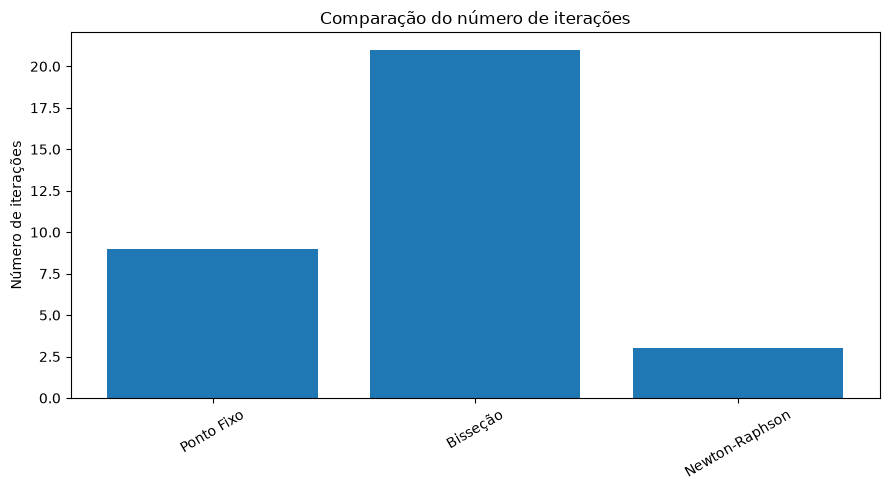

In [14]:
plt.figure(figsize=(9, 5))
plt.bar(
    tabela_comparativa["Método"],
    tabela_comparativa["Iterações"]
)
plt.ylabel("Número de iterações")
plt.title("Comparação do número de iterações")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

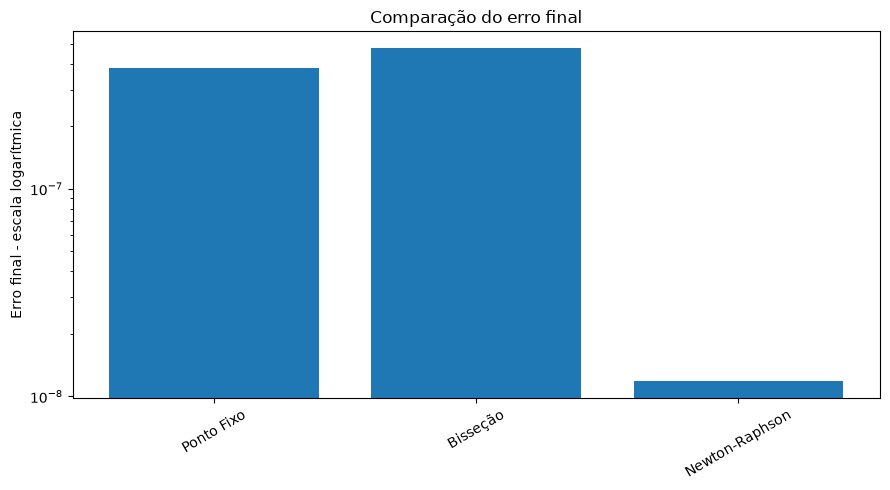

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(
    tabela_comparativa["Método"],
    tabela_comparativa["Erro final"]
)
plt.yscale("log")
plt.ylabel("Erro final - escala logarítmica")
plt.title("Comparação do erro final")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

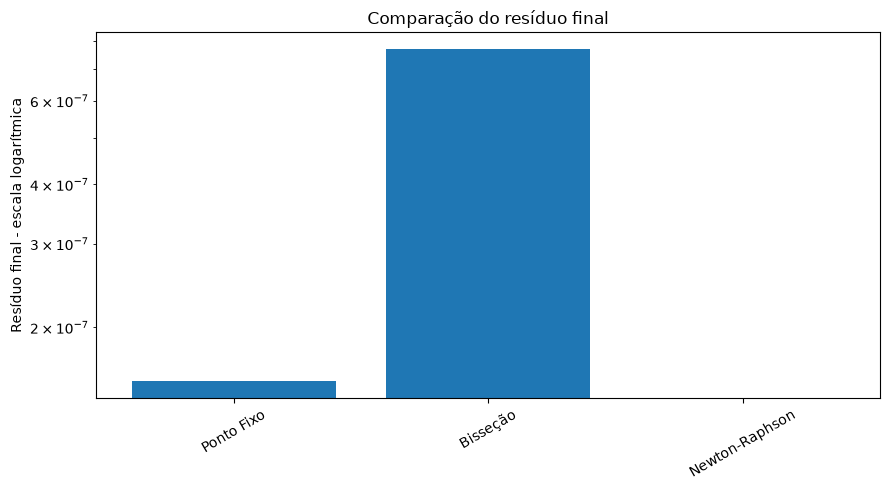

In [16]:
plt.figure(figsize=(9, 5))
plt.bar(
    tabela_comparativa["Método"],
    tabela_comparativa["Resíduo final"]
)
plt.yscale("log")
plt.ylabel("Resíduo final - escala logarítmica")
plt.title("Comparação do resíduo final")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Convergência das aproximações

O gráfico seguinte utiliza os históricos retornados pelos métodos. Como os nomes das colunas de aproximação podem variar entre os algoritmos, a célula procura automaticamente uma coluna adequada para cada histórico.

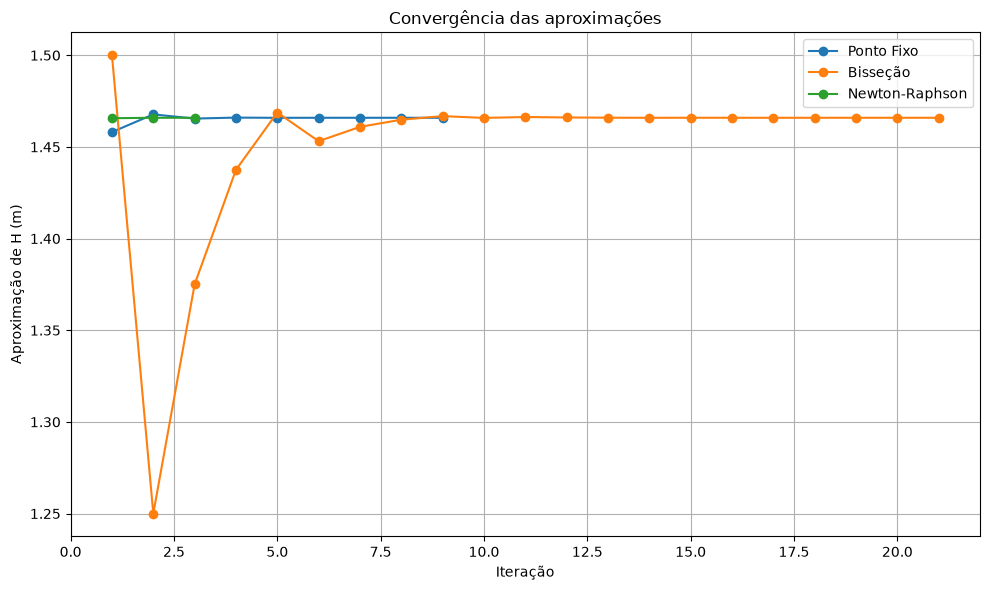

In [17]:
def obter_aproximacoes(historico):
    df = pd.DataFrame(historico)

    candidatos = [
        "x_atual",
        "x_n_mais_1",
        "x",
        "c",
        "raiz",
        "aproximacao",
    ]

    for coluna in candidatos:
        if coluna in df.columns:
            return df[coluna].tolist()

    numericas = [
        coluna
        for coluna in df.columns
        if coluna != "iteracao"
        and pd.api.types.is_numeric_dtype(df[coluna])
    ]

    if numericas:
        return df[numericas[-1]].tolist()

    return []

plt.figure(figsize=(10, 6))

for metodo, resultado in resultados.items():
    aproximacoes = obter_aproximacoes(
        resultado["historico"]
    )

    if aproximacoes:
        iteracoes = range(1, len(aproximacoes) + 1)

        plt.plot(
            iteracoes,
            aproximacoes,
            marker="o",
            label=metodo,
        )

plt.xlabel("Iteração")
plt.ylabel("Aproximação de H (m)")
plt.title("Convergência das aproximações")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<a id="analise"></a>
# 6. ANÁLISE COMPARATIVA

A comparação deve considerar não apenas a aproximação final obtida, mas também o custo iterativo e as características de cada método.

A **Bisseção** possui a vantagem do confinamento da raiz e redução determinística do intervalo. Seu comportamento é previsível, e o número necessário de reduções pode ser estimado previamente mediante logaritmos. Em contrapartida, a convergência tende a ser mais lenta que a de métodos abertos.

A **Falsa Posição** também preserva um intervalo com mudança de sinal, porém utiliza interpolação linear para calcular a nova aproximação. Dependendo da forma da função, pode exigir menos iterações que a Bisseção, embora possa apresentar retenção prolongada de um dos extremos.

O **Ponto Fixo** depende da escolha da função de iteração \(\phi(H)\). Para a formulação adotada neste problema, a convergência deve ser analisada em conjunto com o comportamento de \(\phi\) no intervalo considerado.

O **Newton-Raphson** normalmente apresenta convergência rápida quando a aproximação inicial é adequada e a derivada não se anula nas proximidades da raiz. Sua principal exigência adicional é a disponibilidade da derivada \(f'(H)\).

A **Secante** busca parte da rapidez dos métodos abertos sem exigir derivada analítica. Para isso, utiliza duas aproximações anteriores para construir uma inclinação aproximada.

A tabela e os gráficos gerados acima permitem verificar, no problema estudado, qual método atingiu os critérios definidos com menor número de iterações e quais apresentaram menores valores finais de erro e resíduo.

A conclusão quantitativa deve ser feita diretamente a partir dos resultados produzidos pelo pacote, evitando classificar previamente um método como superior sem considerar as medidas efetivamente obtidas.

In [18]:
metodos_convergentes = tabela_comparativa[
    tabela_comparativa["Convergiu"] == True
]

if not metodos_convergentes.empty:
    mais_rapido = metodos_convergentes.loc[
        metodos_convergentes["Iterações"].idxmin()
    ]

    menor_residuo = metodos_convergentes.loc[
        metodos_convergentes["Resíduo final"].idxmin()
    ]

    print(
        "Menor número de iterações:",
        mais_rapido["Método"],
        "-",
        int(mais_rapido["Iterações"]),
        "iterações"
    )

    print(
        "Menor resíduo final:",
        menor_residuo["Método"],
        "-",
        f'{menor_residuo["Resíduo final"]:.12e}'
    )
else:
    print("Nenhum método foi registrado como convergente.")

Menor número de iterações: Newton-Raphson - 3 iterações
Menor resíduo final: Newton-Raphson - 0.000000000000e+00


<a id="conclusao"></a>
# 7. CONCLUSÃO

O problema foi formulado como uma equação não linear \(f(H)=0\), mantendo a mesma função residual para todos os métodos. A análise do domínio indicou \(H\geq0\), e a mudança de sinal entre \(H=1\) e \(H=2\), associada à continuidade, permitiu estabelecer o intervalo inicial \([1,2]\). A análise da derivada mostrou que a função é estritamente crescente para \(H>0\), garantindo a unicidade da raiz no intervalo considerado.

Foram definidos dois critérios simultâneos de convergência: a estabilização entre aproximações consecutivas e o resíduo da equação, ambos com tolerância \(10^{-6}\). Também foi estabelecido um máximo de 100 iterações como mecanismo de segurança, valor respaldado por precedente em estudo comparativo recente de métodos de determinação de raízes e por documentação técnica de software de análise numérica.

A comparação final entre Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante deve ser interpretada a partir da tabela e dos gráficos produzidos durante a execução do notebook. Essa abordagem permite avaliar conjuntamente aproximação final, número de iterações, erro, resíduo e convergência, mantendo os mesmos critérios numéricos para todos os métodos.

<a id="referencias"></a>
# REFERÊNCIAS

BRENT, R. P. An algorithm with guaranteed convergence for finding a zero of a function. *The Computer Journal*, Oxford, v. 14, n. 4, p. 422-425, 1971. DOI: 10.1093/comjnl/14.4.422. Disponível em: https://doi.org/10.1093/comjnl/14.4.422. Acesso em: 11 set. 2026.

CORDERO, A.; TORREGROSA, J. R. A class of multi-point iterative methods for nonlinear equations. *Applied Mathematics and Computation*, Amsterdam, v. 197, n. 1, p. 337-344, 2008. DOI: 10.1016/j.amc.2007.07.047. Disponível em: https://doi.org/10.1016/j.amc.2007.07.047. Acesso em: 11 set. 2026.

HUANG, N.; MA, C. Convergence analysis and numerical study of a fixed-point iterative method for solving systems of nonlinear equations. *The Scientific World Journal*, [S. l.], v. 2014, Article ID 789459, p. 1-10, 2014. DOI: 10.1155/2014/789459. Disponível em: https://doi.org/10.1155/2014/789459. Acesso em: 11 set. 2026.

IGARASHI, M. Practical problems arising for finding roots of nonlinear equations. *Applied Numerical Mathematics*, Amsterdam, v. 1, n. 5, p. 433-455, 1985a. DOI: 10.1016/0168-9274(85)90005-4. Disponível em: https://doi.org/10.1016/0168-9274(85)90005-4. Acesso em: 11 set. 2026.

IGARASHI, M. Practical stopping rule for finding roots of non-linear equations. *Journal of Computational and Applied Mathematics*, v. 12-13, p. 371-380, 1985b. DOI: 10.1016/0377-0427(85)90031-7. Disponível em: https://doi.org/10.1016/0377-0427(85)90031-7. Acesso em: 11 set. 2026.

RAO, K.; MALAN, P.; PEROT, J. B. A stopping criterion for the iterative solution of partial differential equations. *Journal of Computational Physics*, Amsterdam, v. 352, p. 265-284, 2018. DOI: 10.1016/j.jcp.2017.09.033. Disponível em: https://doi.org/10.1016/j.jcp.2017.09.033. Acesso em: 11 set. 2026.

SCHERZER, O. Convergence criteria of iterative methods based on Landweber iteration for solving nonlinear problems. *Journal of Mathematical Analysis and Applications*, [S. l.], v. 194, n. 3, p. 911-933, 1995. DOI: 10.1006/jmaa.1995.1335. Disponível em: https://doi.org/10.1006/jmaa.1995.1335. Acesso em: 11 set. 2026.

SIKORSKI, K.; WOŹNIAKOWSKI, H. For which error criteria can we solve nonlinear equations? *Journal of Complexity*, [S. l.], v. 2, n. 2, p. 163-178, 1986. DOI: 10.1016/0885-064X(86)90017-8. Disponível em: https://doi.org/10.1016/0885-064X(86)90017-8. Acesso em: 11 set. 2026.

SHARMA, R.; CHOUHAN, V. S. Computational performance of classical and hybrid root-finding methods for real-world nonlinear models. *Discover Computing*, v. 29, art. 252, 2026. DOI: 10.1007/s10791-026-10141-w. Disponível em: https://doi.org/10.1007/s10791-026-10141-w. Acesso em: 15 set. 2026.
